In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import glob
from sklearn.metrics import mean_squared_error
# from sklearn.linear_model import LinearRegreossion
import statsmodels.api as sm
from learners_reg import Net

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
n = 100

def draw_x(n):
    # Generate n datapoints, uniform between -1 and 1
    return -1 + 2 * np.random.rand(n)

def reward(x, a = 1, c = 0.5):
    # Reward is 0 if a = 0 and is quadratic if a = 1
    return a*(x + c * x**2)

def fit_model_mse(x,r):
    # Pass in (x,r) pairs for datapoints where a = 1
    #X = x.reshape(-1, 1)  # Reshape to column vector
    #model = LinearRegression()
    #model.fit(X, r)

    #theta0 = model.intercept_
    #theta1 = model.coef_[0]
    model = sm.OLS(r, sm.add_constant(x))
    results = model.fit()

    return results.params # intercept, slope




[0.16838425 0.98425699]


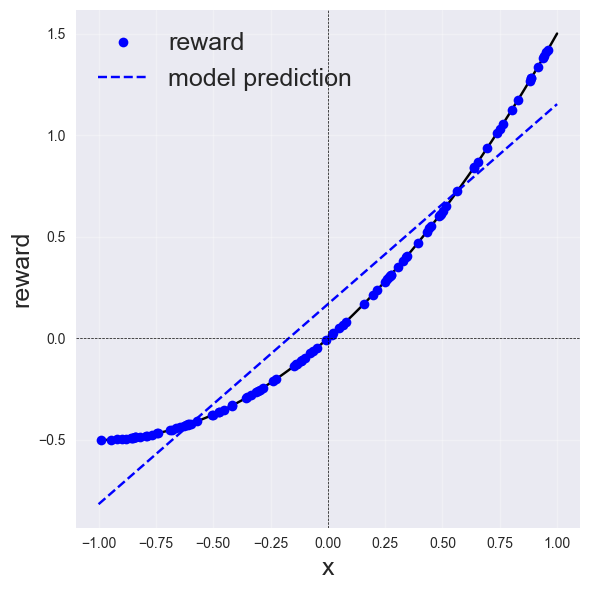

In [51]:
c = 0.5

# Generate data
x = draw_x(n)
r = reward(x,c=c)
theta_hat_mse = fit_model_mse(x,r)
print(theta_hat_mse)

# Plot of x + cx^2 vs x
# _x and _r are x
_x = np.linspace(-1, 1, 100)
r_true = reward(_x,c=c)

r_hat_mse = theta_hat_mse[0] + theta_hat_mse[1]*_x


plt.figure(figsize=(6, 6))
plt.plot(_x, r_true, 'k-')
plt.plot(x, r, 'bo',label='reward')
plt.plot(_x, r_hat_mse, 'b--',label='model prediction')

plt.xlabel('x', fontsize=18)
plt.ylabel('reward', fontsize=18)
# plt.title('Plot of x + cx² vs x', fontsize=14, fontweight='bold')
# plt.legend(['reward', 'model prediction'],loc='best')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
# plt.savefig('plot_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

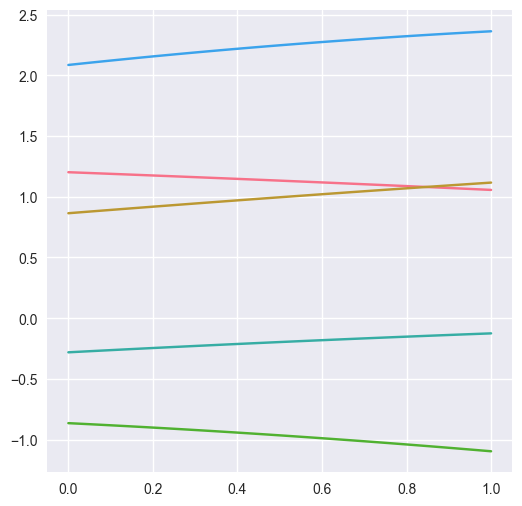

In [57]:
# PLot for early in the deck

num_lines = 5
intercepts = np.random.randn(num_lines)
slopes = 0.2*np.random.randn(num_lines)
quadratic = -0.1*np.random.rand(num_lines)

plt.figure(figsize=(6, 6))

_x = np.linspace(0, 1, 100)
for i in range(num_lines):
    _y = intercepts[i] + slopes[i]*_x + quadratic[i]*_x**2
    plt.plot(_x,_y,'-')




[0.04523725 1.13010177]


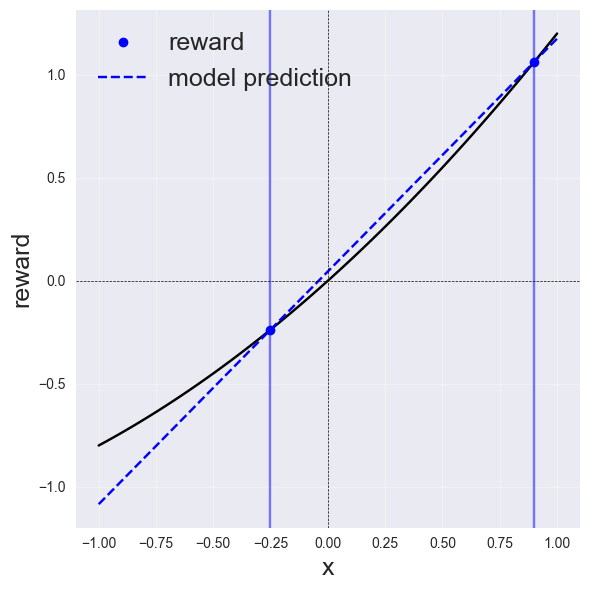

In [72]:
c = 0.2
np.random.seed(42)
n = 2

# Generate data
x = draw_x(n)
r = reward(x,c=c)
theta_hat_mse = fit_model_mse(x,r)
print(theta_hat_mse)

# Plot of x + cx^2 vs x
# _x and _r are x
_x = np.linspace(-1, 1, 100)
r_true = reward(_x,c=c)

r_hat_mse = theta_hat_mse[0] + theta_hat_mse[1]*_x

# Find the largest point in x that is below 0 
L = np.max(x[x<0])
U = np.min(x[x>0])



plt.figure(figsize=(6, 6))
plt.plot(_x, r_true, 'k-')
plt.plot(x, r, 'bo',label='reward')
plt.plot(_x, r_hat_mse, 'b--',label='model prediction')

plt.axvline(L,alpha=0.5,color='b')
plt.axvline(U,alpha=0.5,color='b')

plt.xlabel('x', fontsize=18)
plt.ylabel('reward', fontsize=18)
# plt.title('Plot of x + cx² vs x', fontsize=14, fontweight='bold')
# plt.legend(['reward', 'model prediction'],loc='best')
plt.legend(fontsize=18)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.tight_layout()
# plt.savefig('plot_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:

def get_expected_reward(thresh, c):
    _x = np.linspace(-1, 1, 100)
    return reward(_x[_x > thresh], c=c).sum() / len(_x)


def run_one_xp(n,c,seed):

    np.random.seed(seed)
    x = draw_x(n)
    r = reward(x,c=c)

    # run MSE
    theta_hat_mse = fit_model_mse(x,r)
    thresh_mse = -theta_hat_mse[0] / theta_hat_mse[1]

    # Run regret
    if len(x[x<0]) == 0:
        L = -1
    else:
        L = np.max(x[x<0])

    if len(x[x>0]) == 0:
        U = 1
    else:
        U = np.min(x[x>0])
    thresh_esr = (L+U)/2

    expected_reward_mse = get_expected_reward(thresh_mse, c)
    expected_reward_esr = get_expected_reward(thresh_esr, c)

    return expected_reward_mse, expected_reward_esr 

def run_xp(n,c,n_reps=10):

    mse = []
    esr = []

    for seed in range(n_reps):
        _mse, _esr = run_one_xp(n,c,seed)
        mse.append(_mse)
        esr.append(_esr)

    return np.mean(mse), np.std(mse)/np.sqrt(n_reps), np.mean(esr), np.std(esr)/np.sqrt(n_reps), 






In [ ]:
df = pd.DataFrame(columns=['n', 'c', 'mse', 'mse_stderr', 'esr', 'esr_stderr'])

c = 0.2
for n in [2,4,8,16,32,64,128]:
    mse, mse_stderr, esr, esr_stderr = run_xp(n,c)
    df.loc[len(df)] = [n,c,mse,mse_stderr,esr,esr_stderr]

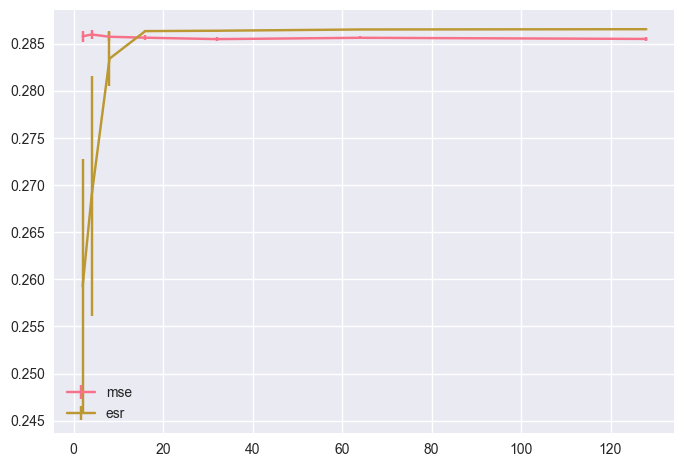

In [ ]:
plt.errorbar(df['n'],df['mse'],1.96*df['mse_stderr'],label='mse')
plt.errorbar(df['n'],df['esr'],1.96*df['esr_stderr'],label='esr')
plt.legend(loc='best')
plt.ylabel('Expected reward')
plt.xlabel('')

In [66]:
np.min(x[x>0])

np.float64(0.4406489868843162)

In [3]:
df = pd.read_csv('out2.csv',header=0)

In [4]:
df.head()

,train_loss,train_regret,test_regret,train_mse
0,3.977049,0.318541,0.317685,0.413507
1,3.206944,0.319097,0.316484,0.378763
2,0.057778,0.318714,0.316111,0.784322
3,3.125766,0.319097,0.316484,0.376514
4,3.046676,0.319097,0.316484,0.374393


In [5]:
df.columns

Index(['train_loss', 'train_regret', 'test_regret', 'train_mse'], dtype='object')

In [6]:
df['train_mse']

0     0.413507
1     0.378763
2     0.784322
3     0.376514
4     0.374393
        ...   
95    0.765783
96    0.769825
97    0.773837
98    0.777483
99    0.780955
Name: train_mse, Length: 100, dtype: float64

Text(0, 0.5, 'train_mse')

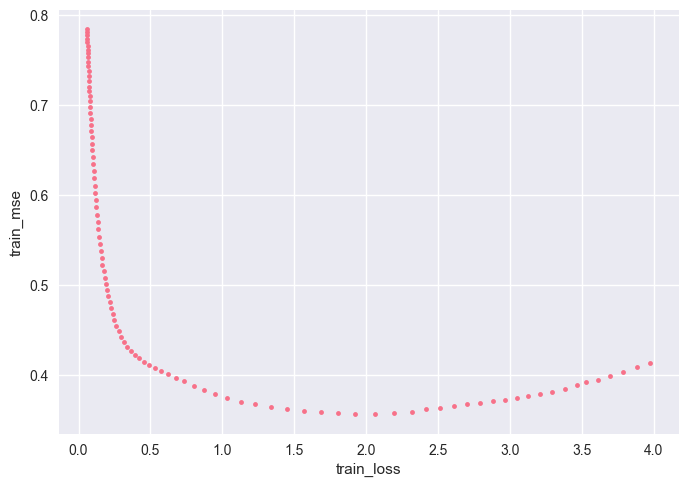

In [7]:
plt.plot(df['train_loss'],df['train_mse'],'.')
plt.xlabel('train_loss')
plt.ylabel('train_mse')

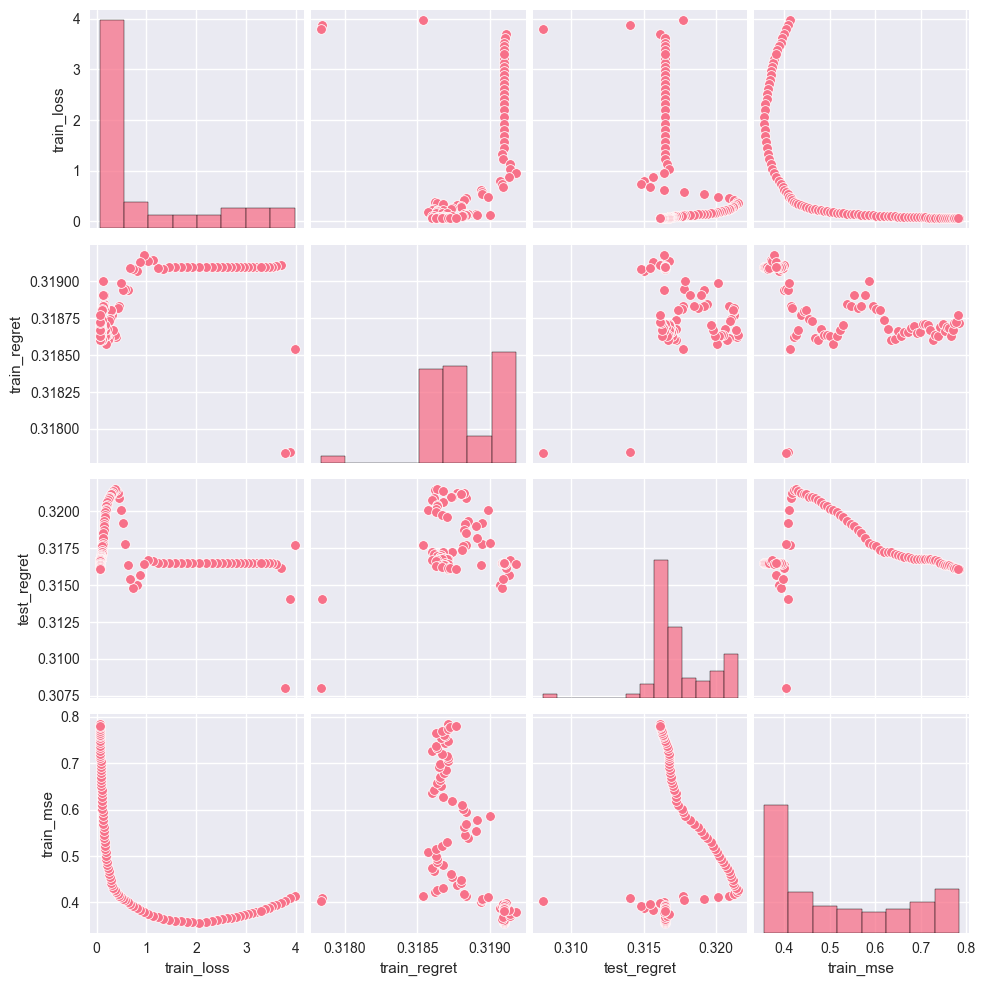

In [8]:
sns.pairplot(df)

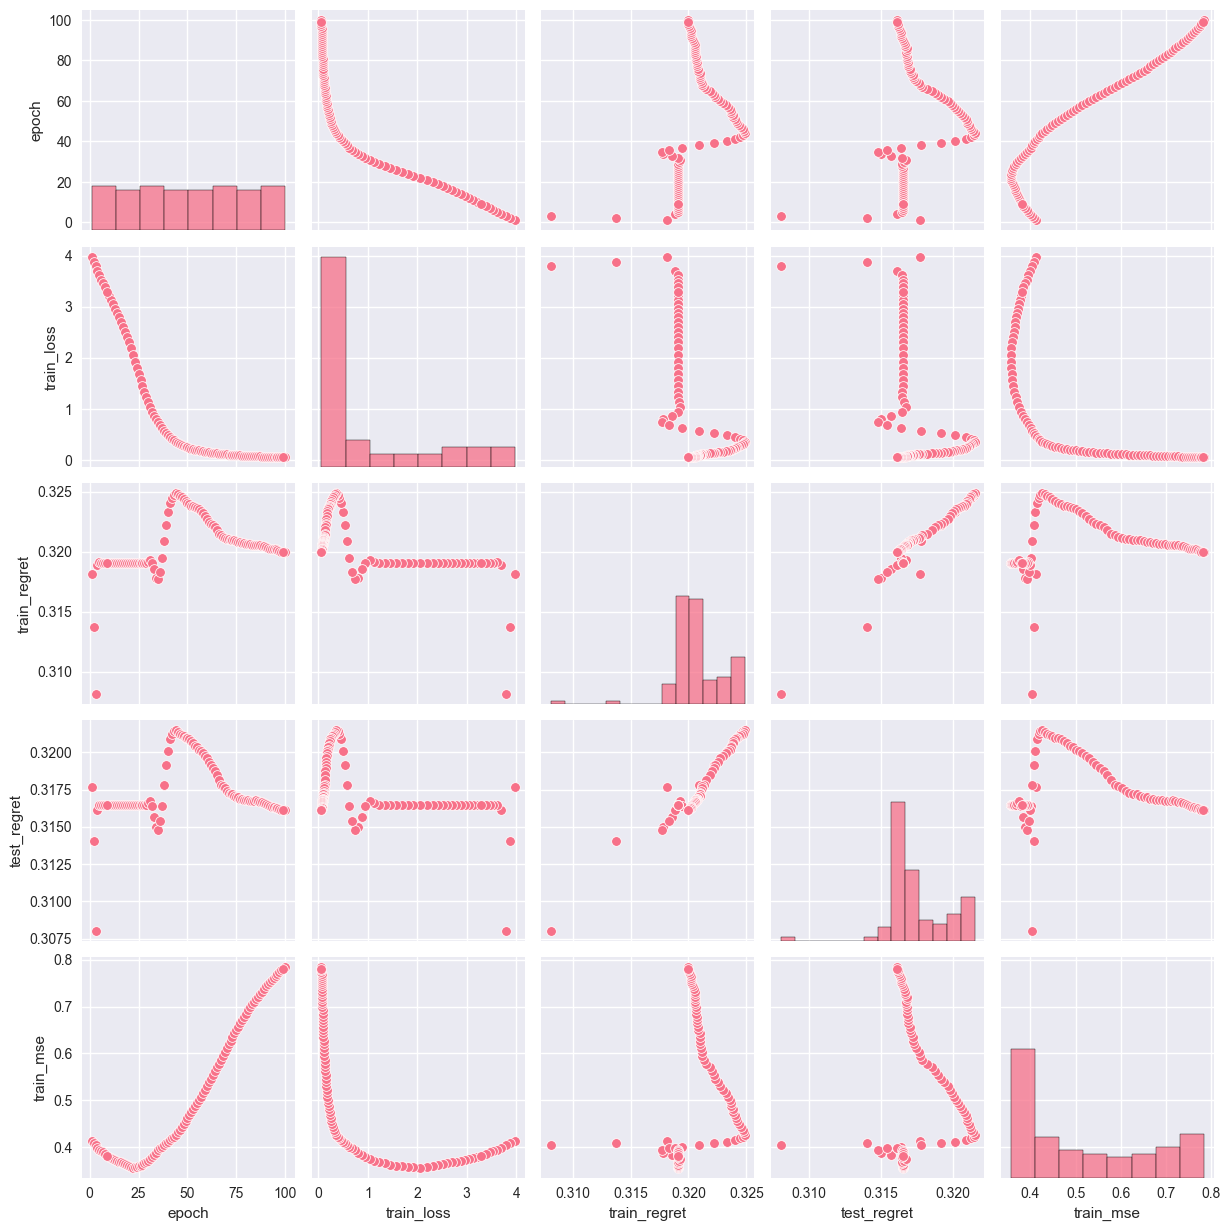

In [9]:
df1 = pd.read_csv('XP1.csv')
sns.pairplot(df1)

In [10]:

num_df = 21

df = [pd.DataFrame()]*num_df
for i in range(num_df):
    df[i] = pd.read_csv(f'XP{i+1:02d}.csv')

for i in range(num_df):
    test_regret = df[i]['test_regret'].iloc[-1]
    print(f'XP{i+1}, test_regret={test_regret}')

XP1, test_regret=0.316106
XP2, test_regret=0.318134
XP3, test_regret=0.313729
XP4, test_regret=0.312269
XP5, test_regret=0.335653
XP6, test_regret=0.342433
XP7, test_regret=0.317641
XP8, test_regret=0.31898
XP9, test_regret=0.318356
XP10, test_regret=0.307851
XP11, test_regret=0.318647
XP12, test_regret=0.318181
XP13, test_regret=0.324017
XP14, test_regret=0.311243
XP15, test_regret=0.330048
XP16, test_regret=0.321594
XP17, test_regret=0.314357
XP18, test_regret=0.328967
XP19, test_regret=0.316056
XP20, test_regret=0.315972
XP21, test_regret=0.332829


# Autogenerated stuff from Cursor -- probably discard

## Load Data and Setup


In [11]:
# Load test data for computing MSE
try:
    data = np.load('informs.npz')
    xs_train = data['xs_train']
    treats_train = data['treats_train']
    outcomes_train = data['outcomes_train']
    print(f"✓ Loaded data: {xs_train.shape[0]} training samples, {xs_train.shape[1]} features")
except FileNotFoundError:
    print("✗ Data file 'informs.npz' not found. Please ensure data is available.")
    # Create dummy data for demonstration
    np.random.seed(42)
    xs_train = np.random.randn(1000, 25)
    treats_train = np.random.binomial(1, 0.5, 1000)
    outcomes_train = np.random.randn(1000)
    print("⚠️  Using dummy data for demonstration")


✓ Loaded data: 100000 training samples, 50 features


## Load and Analyze Model Checkpoints


In [12]:
def load_and_analyze_models(model_save_dir="model_weights"):
    """Load model checkpoints and compute training metrics."""
    
    if not os.path.exists(model_save_dir):
        print(f"✗ Model directory '{model_save_dir}' not found!")
        return pd.DataFrame()
    
    model_files = glob.glob(os.path.join(model_save_dir, "*.pth"))
    
    if not model_files:
        print(f"✗ No model files found in '{model_save_dir}'!")
        return pd.DataFrame()
    
    print(f"✓ Found {len(model_files)} model files")
    
    results = []
    
    for model_file in sorted(model_files):
        filename = os.path.basename(model_file)
        print(f"  Analyzing: {filename}")
        
        try:
            # Load checkpoint
            checkpoint = torch.load(model_file, map_location='cpu', weights_only=False)
            
            # Extract metadata
            epoch = checkpoint.get('epoch', 0)
            train_loss = checkpoint.get('train_loss', 0)
            n_train = checkpoint.get('n_train', len(xs_train))
            k_param = checkpoint.get('k', None)
            
            # Determine model type from filename
            if "reg_learner" in filename:
                model_type = "reg_learner"
            elif "s_learner" in filename:
                model_type = "s_learner"
            elif "t_learner" in filename:
                model_type = "t_learner"
            elif "r_learner" in filename:
                model_type = "r_learner"
            elif "dr_learner" in filename:
                model_type = "dr_learner"
            else:
                model_type = "unknown"
            
            # Create model and compute training MSE
            _, d = xs_train.shape
            model = Net(d+1).to('cpu')
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            
            # Compute training MSE
            with torch.no_grad():
                # Use subset of training data if specified
                n_train_actual = min(n_train, len(xs_train))
                xs_subset = xs_train[:n_train_actual]
                treats_subset = treats_train[:n_train_actual]
                outcomes_subset = outcomes_train[:n_train_actual]
                
                # Prepare input for model
                X_train = np.concatenate((xs_subset, np.expand_dims(treats_subset, axis=1)), axis=1)
                train_pred = model(torch.tensor(X_train, dtype=torch.float64)).numpy()
                
                # Compute MSE
                train_mse = mean_squared_error(outcomes_subset, train_pred)
            
            # Store results
            results.append({
                'filename': filename,
                'model_type': model_type,
                'epoch': epoch,
                'train_loss': train_loss,
                'train_mse': train_mse,
                'n_train': n_train_actual,
                'k_param': k_param
            })
            
        except Exception as e:
            print(f"    ✗ Error loading {filename}: {e}")
            continue
    
    return pd.DataFrame(results)

# Load models from default directory
df = load_and_analyze_models()
print(f"\n📊 Loaded {len(df)} model checkpoints")


✓ Found 100 model files
  Analyzing: reg_learner_epoch_1.pth
    ✗ Error loading reg_learner_epoch_1.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a param with shape torch.Size([5, 3]) from checkpoint, the shape in current model is torch.Size([5, 51]).
  Analyzing: reg_learner_epoch_10.pth
    ✗ Error loading reg_learner_epoch_10.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a param with shape torch.Size([5, 3]) from checkpoint, the shape in current model is torch.Size([5, 51]).
  Analyzing: reg_learner_epoch_100.pth
    ✗ Error loading reg_learner_epoch_100.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a param with shape torch.Size([5, 3]) from checkpoint, the shape in current model is torch.Size([5, 51]).
  Analyzing: reg_learner_epoch_11.pth
    ✗ Error loading reg_learner_epoch_11.pth: Error(s) in loading state_dict for Net:
	size mismatch for lin.weight: copying a para

## Display Results Table


In [13]:
if not df.empty:
    print("📋 Model Analysis Results:")
    print("=" * 80)
    
    # Display summary statistics
    print("\n📈 Summary Statistics:")
    print(df[['train_loss', 'train_mse']].describe())
    
    # Display detailed results
    print("\n📊 Detailed Results:")
    display(df[['filename', 'model_type', 'epoch', 'train_loss', 'train_mse', 'n_train', 'k_param']])
else:
    print("✗ No model data available for analysis")


✗ No model data available for analysis


## Create Training Loss vs Training MSE Plot


In [14]:
if not df.empty:
    # Create the main plot
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot with different colors for different model types
    model_types = df['model_type'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(model_types)))
    
    for i, model_type in enumerate(model_types):
        mask = df['model_type'] == model_type
        subset = df[mask]
        
        plt.scatter(subset['train_loss'], subset['train_mse'], 
                   c=[colors[i]], label=f'{model_type} (n={len(subset)})', 
                   alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
    
    # Add trend line
    if len(df) > 1:
        z = np.polyfit(df['train_loss'], df['train_mse'], 1)
        p = np.poly1d(z)
        plt.plot(df['train_loss'], p(df['train_loss']), 
                "r--", alpha=0.8, linewidth=2, label=f'Trend (slope={z[0]:.3f})')
    
    plt.xlabel('Training Loss', fontsize=14)
    plt.ylabel('Training MSE', fontsize=14)
    plt.title('Training Loss vs Training MSE\nModel Performance Analysis', fontsize=16, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Add correlation coefficient
    correlation = df['train_loss'].corr(df['train_mse'])
    plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
             transform=plt.gca().transAxes, fontsize=12, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"📊 Correlation between Training Loss and Training MSE: {correlation:.3f}")
else:
    print("✗ No data available for plotting")


✗ No data available for plotting
